In [3]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_wine 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
# Load dataset bawaan scikit-learn (klasifikasi 3 kelas) 
data = load_wine() 
X = pd.DataFrame(data.data, columns=data.feature_names) 
y = data.target 
# Split data menjadi Train (80%) dan Validation (20%) 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y) 
# Feature Scaling (Sangat penting untuk SVM) 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_val_scaled = scaler.transform(X_val) 
print(f"Dimensi Training: {X_train_scaled.shape}") 
print(f"Dimensi Validation: {X_val_scaled.shape}")

Dimensi Training: (142, 13)
Dimensi Validation: (36, 13)


In [4]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 

# 1. Inisialisasi Model 
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5) 
svm_model = SVC(kernel='rbf', C=1.0, random_state=42) 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Pelatihan (Fit) menggunakan data training yang sudah di-scale 
dt_model.fit(X_train_scaled, y_train) 
svm_model.fit(X_train_scaled, y_train) 
rf_model.fit(X_train_scaled, y_train) 

# 3. Prediksi (Predict) pada data validasi 
dt_preds = dt_model.predict(X_val_scaled) 
svm_preds = svm_model.predict(X_val_scaled) 
rf_preds = rf_model.predict(X_val_scaled) 
print("Proses training dan inferensi selesai.")

Proses training dan inferensi selesai.


--- Evaluasi Model: Decision Tree ---
Balanced Accuracy: 0.9389

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



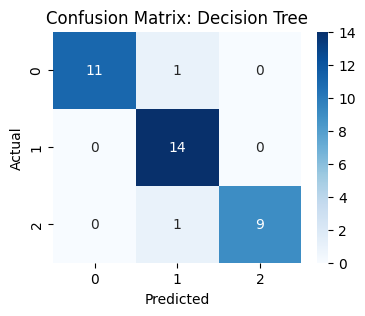

--- Evaluasi Model: SVM ---
Balanced Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



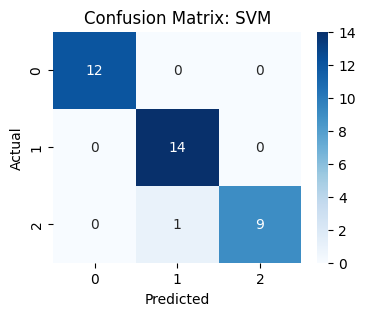

--- Evaluasi Model: Random Forest ---
Balanced Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



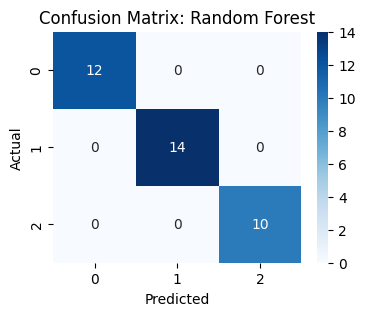

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# Fungsi evaluasi model
def evaluate_model(name, y_true, y_pred):
    print(f"--- Evaluasi Model: {name} ---")

    # 1. Balanced Accuracy
    b_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Balanced Accuracy: {b_acc:.4f}\n")

    # 2. Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # 3. Confusion Matrix (Visual)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# Evaluasi semua model
evaluate_model("Decision Tree", y_val, dt_preds)
evaluate_model("SVM", y_val, svm_preds)
evaluate_model("Random Forest", y_val, rf_preds)